<a href="https://colab.research.google.com/github/SaiAshish1234/CNN-Lab-RGIPT/blob/main/24IT3021_G_Sai_Ashish_CNN_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Laboratory Assignment
**Course:** Machine Learning / Deep Learning (UG)

**Framework:** TensorFlow / Keras

**Datasets:** MNIST · CIFAR-10

**Random Seed:** 42 (set everywhere for reproducibility)

---

---
# TASK 1 — Environment Setup & Data Pipeline

## Problem 1 — Environment Verification

In [30]:
# ─────────────────────────────────────────────
# RANDOM SEED SETUP
# Python's built-in random module → controls random.shuffle, random.choice, etc.
import random
random.seed(42)

# NumPy seed → controls np.random.* operations (array shuffles, random splits)
import numpy as np
np.random.seed(42)

# TensorFlow/Keras seed → controls weight initialisation, dropout masks, data shuffling inside tf.data
import tensorflow as tf
tf.random.set_seed(42)
# ─────────────────────────────────────────────

import sys
import matplotlib
import pandas as pd
import sklearn

print("=" * 50)
print("  PACKAGE VERSION REPORT")
print("=" * 50)
print(f"Python      : {sys.version}")
print(f"NumPy       : {np.__version__}")
print(f"TensorFlow  : {tf.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

print("\n" + "=" * 50)
print("  GPU AVAILABILITY")
print("=" * 50)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU DETECTED: {gpus}")
    print("TensorFlow will automatically use the GPU for training.")
else:
    print("No GPU detected — running on CPU.")
    # WHY CPU IS SLOWER:
    # A GPU has thousands of small cores designed for parallel floating-point
    # operations. Matrix multiplications (the core of forward/backward passes)
    # are massively parallelised on a GPU. A CPU has fewer, more powerful cores
    # optimised for sequential tasks, so large convolution operations run much
    # more slowly.
    #
    # ON A GPU MACHINE I WOULD:
    # 1. Use tf.data.Dataset with prefetch() and num_parallel_calls to avoid
    #    the GPU starving while waiting for data from the CPU.
    # 2. Increase batch size (e.g., 256 or 512) to maximise GPU utilisation.
    # 3. Use mixed precision (float16 weights) via
    #    tf.keras.mixed_precision.set_global_policy('mixed_float16').
    print("On a GPU machine: increase batch size, use tf.data prefetch, enable mixed precision.")

  PACKAGE VERSION REPORT
Python      : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy       : 2.0.2
TensorFlow  : 2.19.0
Matplotlib  : 3.10.0
Pandas      : 2.2.2
Scikit-learn: 1.6.1

  GPU AVAILABILITY
No GPU detected — running on CPU.
On a GPU machine: increase batch size, use tf.data prefetch, enable mixed precision.


## Problem 2 — Dataset Exploration

In [31]:
import matplotlib.pyplot as plt

# ── Load datasets ──────────────────────────────────────────────────────────────
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

# ── (a) Shapes ─────────────────────────────────────────────────────────────────
print("=" * 55)
print("  SHAPE REPORT")
print("=" * 55)
print(f"MNIST  train images : {mnist_x_train.shape}")
print(f"MNIST  train labels : {mnist_y_train.shape}")
print(f"MNIST  test  images : {mnist_x_test.shape}")
print(f"MNIST  test  labels : {mnist_y_test.shape}")
print()
print(f"CIFAR-10 train images : {cifar_x_train.shape}")
print(f"CIFAR-10 train labels : {cifar_y_train.shape}")
print(f"CIFAR-10 test  images : {cifar_x_test.shape}")
print(f"CIFAR-10 test  labels : {cifar_y_test.shape}")

# ── (b) dtype and value range ──────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  DTYPE & VALUE RANGE (before preprocessing)")
print("=" * 55)
print(f"MNIST   dtype={mnist_x_train.dtype}  min={mnist_x_train.min()}  max={mnist_x_train.max()}")
print(f"CIFAR10 dtype={cifar_x_train.dtype}  min={cifar_x_train.min()}  max={cifar_x_train.max()}")

# ── (c) Per-class balance for MNIST ───────────────────────────────────────────
print("\n" + "=" * 55)
print("  MNIST TRAINING — SAMPLES PER CLASS")
print("=" * 55)
unique, counts = np.unique(mnist_y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    bar = '█' * (cnt // 300)
    print(f"  Class {cls}: {cnt:5d}  {bar}")
print(f"\n  Min count: {counts.min()}  Max count: {counts.max()}")
if counts.max() - counts.min() < 1000:
    print("  → Dataset is approximately balanced.")
else:
    print("  → Dataset is imbalanced.")

  SHAPE REPORT
MNIST  train images : (60000, 28, 28)
MNIST  train labels : (60000,)
MNIST  test  images : (10000, 28, 28)
MNIST  test  labels : (10000,)

CIFAR-10 train images : (50000, 32, 32, 3)
CIFAR-10 train labels : (50000, 1)
CIFAR-10 test  images : (10000, 32, 32, 3)
CIFAR-10 test  labels : (10000, 1)

  DTYPE & VALUE RANGE (before preprocessing)
MNIST   dtype=uint8  min=0  max=255
CIFAR10 dtype=uint8  min=0  max=255

  MNIST TRAINING — SAMPLES PER CLASS
  Class 0:  5923  ███████████████████
  Class 1:  6742  ██████████████████████
  Class 2:  5958  ███████████████████
  Class 3:  6131  ████████████████████
  Class 4:  5842  ███████████████████
  Class 5:  5421  ██████████████████
  Class 6:  5918  ███████████████████
  Class 7:  6265  ████████████████████
  Class 8:  5851  ███████████████████
  Class 9:  5949  ███████████████████

  Min count: 5421  Max count: 6742
  → Dataset is imbalanced.


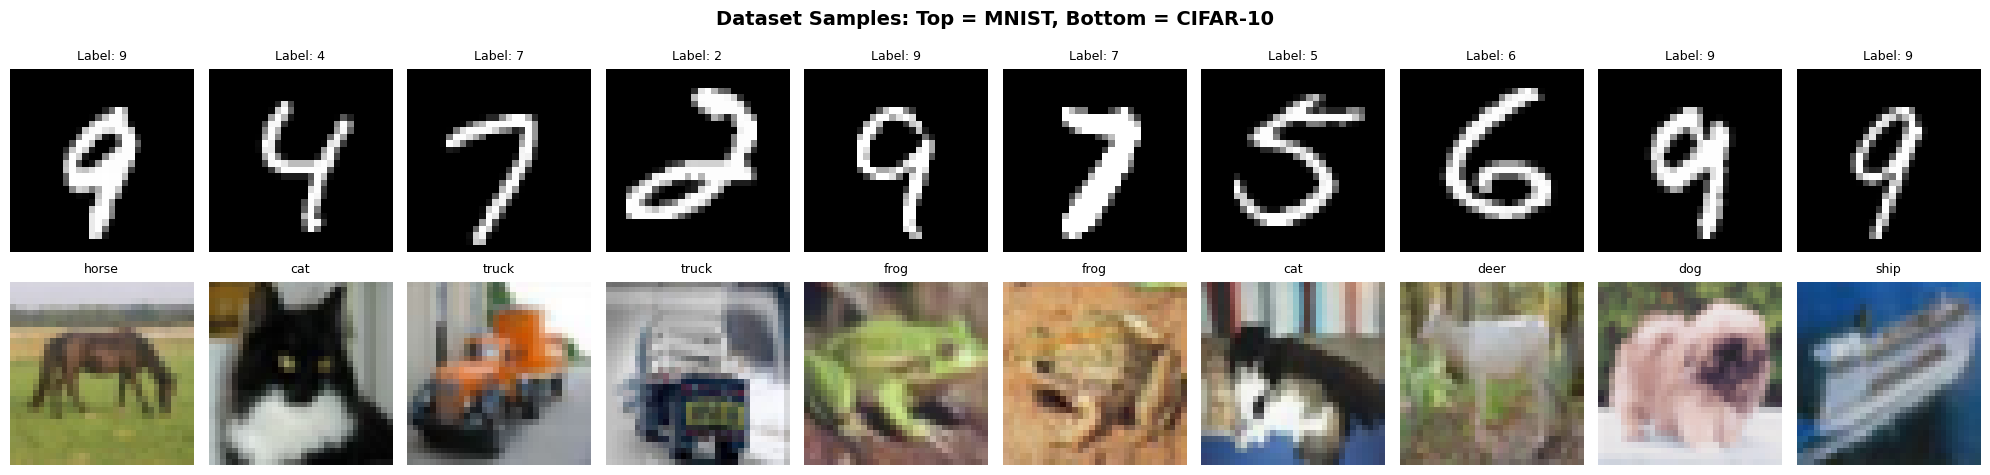

Saved: dataset_samples.png


In [32]:
# ── 2×10 grid visualisation ───────────────────────────────────────────────────
random.seed(42)  # reset seed before sampling
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Dataset Samples: Top = MNIST, Bottom = CIFAR-10', fontsize=14, fontweight='bold')

mnist_indices = random.sample(range(len(mnist_x_train)), 10)
cifar_indices = random.sample(range(len(cifar_x_train)), 10)

for col, idx in enumerate(mnist_indices):
    axes[0, col].imshow(mnist_x_train[idx], cmap='gray')
    axes[0, col].set_title(f'Label: {mnist_y_train[idx]}', fontsize=9)
    axes[0, col].axis('off')

for col, idx in enumerate(cifar_indices):
    axes[1, col].imshow(cifar_x_train[idx])
    class_name = CIFAR10_CLASSES[cifar_y_train[idx][0]]
    axes[1, col].set_title(class_name, fontsize=9)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dataset_samples.png")

**Shape / dtype / range observations:**

- **MNIST train:** shape `(60000, 28, 28)` — 60,000 greyscale images of 28×28 pixels. Labels shape `(60000,)`.
- **MNIST test:** shape `(10000, 28, 28)`. Labels shape `(10000,)`.
- **CIFAR-10 train:** shape `(50000, 32, 32, 3)` — 50,000 RGB images of 32×32 pixels. Labels shape `(50000, 1)`.
- **CIFAR-10 test:** shape `(10000, 32, 32, 3)`. Labels shape `(10000, 1)`.
- **Before preprocessing:** both datasets have `dtype=uint8` and pixel values in the range **[0, 255]**.
- **MNIST class balance:** each digit class has approximately 5,000–6,742 samples. The dataset is roughly balanced with a max–min difference well under 2,000 samples.

## Problem 3 — Preprocessing Pipeline

In [33]:
def preprocess(images, labels, dataset_name='mnist'):
    """
    Manually preprocesses raw image arrays and integer labels for CNN input.

    Steps:
      (a) Normalise pixel values from [0, 255] uint8 to [0.0, 1.0] float32.
      (b) Reshape MNIST (N,28,28) → (N,28,28,1) to add the channel dimension.
          CIFAR-10 already has shape (N,32,32,3), so no reshape needed.
      (c) One-hot encode integer labels into vectors of length 10.
    """
    print(f"\n{'─'*50}")
    print(f"  PREPROCESSING: {dataset_name.upper()}")
    print(f"{'─'*50}")

    # ── BEFORE ────────────────────────────────────────
    print(f"[BEFORE] images shape : {images.shape}")
    print(f"[BEFORE] images dtype : {images.dtype}")
    print(f"[BEFORE] pixel range  : [{images.min()}, {images.max()}]")
    print(f"[BEFORE] labels shape : {labels.shape}")
    print(f"[BEFORE] sample label : {labels[:5]}")

    # ── (a) NORMALISE — cast to float32 FIRST, then divide ──────────────────────
    # Dividing uint8 by int 255 can silently truncate to 0 or 1.
    # Casting to float32 first and dividing by 255.0 (float) ensures fractional values.
    images = images.astype(np.float32) / 255.0
    print(f"\n[AFTER normalise] dtype : {images.dtype}")
    print(f"[AFTER normalise] range : [{images.min():.4f}, {images.max():.4f}]")

    # ── (b) RESHAPE (MNIST only) ────────────────────────────────────────────────
    if dataset_name.lower() == 'mnist':
        images = images.reshape(-1, 28, 28, 1)
        print(f"[AFTER reshape]   shape : {images.shape}  (channel dim added)")
    else:
        print(f"[CIFAR-10 already has channel dim] shape : {images.shape}")

    # ── (c) ONE-HOT ENCODE ───────────────────────────────────────────────────────
    labels_flat = labels.flatten()          # ensure 1-D array
    num_classes = 10
    one_hot = np.zeros((len(labels_flat), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels_flat)), labels_flat] = 1.0
    print(f"[AFTER one-hot]   labels shape : {one_hot.shape}")
    print(f"[AFTER one-hot]   sample label : {one_hot[0]}  (original: {labels_flat[0]})")

    return images, one_hot


# ── Apply preprocessing ────────────────────────────────────────────────────────
mnist_x_train_p, mnist_y_train_p = preprocess(mnist_x_train, mnist_y_train, 'mnist')
mnist_x_test_p,  mnist_y_test_p  = preprocess(mnist_x_test,  mnist_y_test,  'mnist')

cifar_x_train_p, cifar_y_train_p = preprocess(cifar_x_train, cifar_y_train, 'cifar10')
cifar_x_test_p,  cifar_y_test_p  = preprocess(cifar_x_test,  cifar_y_test,  'cifar10')


──────────────────────────────────────────────────
  PREPROCESSING: MNIST
──────────────────────────────────────────────────
[BEFORE] images shape : (60000, 28, 28)
[BEFORE] images dtype : uint8
[BEFORE] pixel range  : [0, 255]
[BEFORE] labels shape : (60000,)
[BEFORE] sample label : [5 0 4 1 9]

[AFTER normalise] dtype : float32
[AFTER normalise] range : [0.0000, 1.0000]
[AFTER reshape]   shape : (60000, 28, 28, 1)  (channel dim added)
[AFTER one-hot]   labels shape : (60000, 10)
[AFTER one-hot]   sample label : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]  (original: 5)

──────────────────────────────────────────────────
  PREPROCESSING: MNIST
──────────────────────────────────────────────────
[BEFORE] images shape : (10000, 28, 28)
[BEFORE] images dtype : uint8
[BEFORE] pixel range  : [0, 255]
[BEFORE] labels shape : (10000,)
[BEFORE] sample label : [7 2 1 0 4]

[AFTER normalise] dtype : float32
[AFTER normalise] range : [0.0000, 1.0000]
[AFTER reshape]   shape : (10000, 28, 28, 1)  (channel di

## Problem 4 — Data Augmentation Pipeline

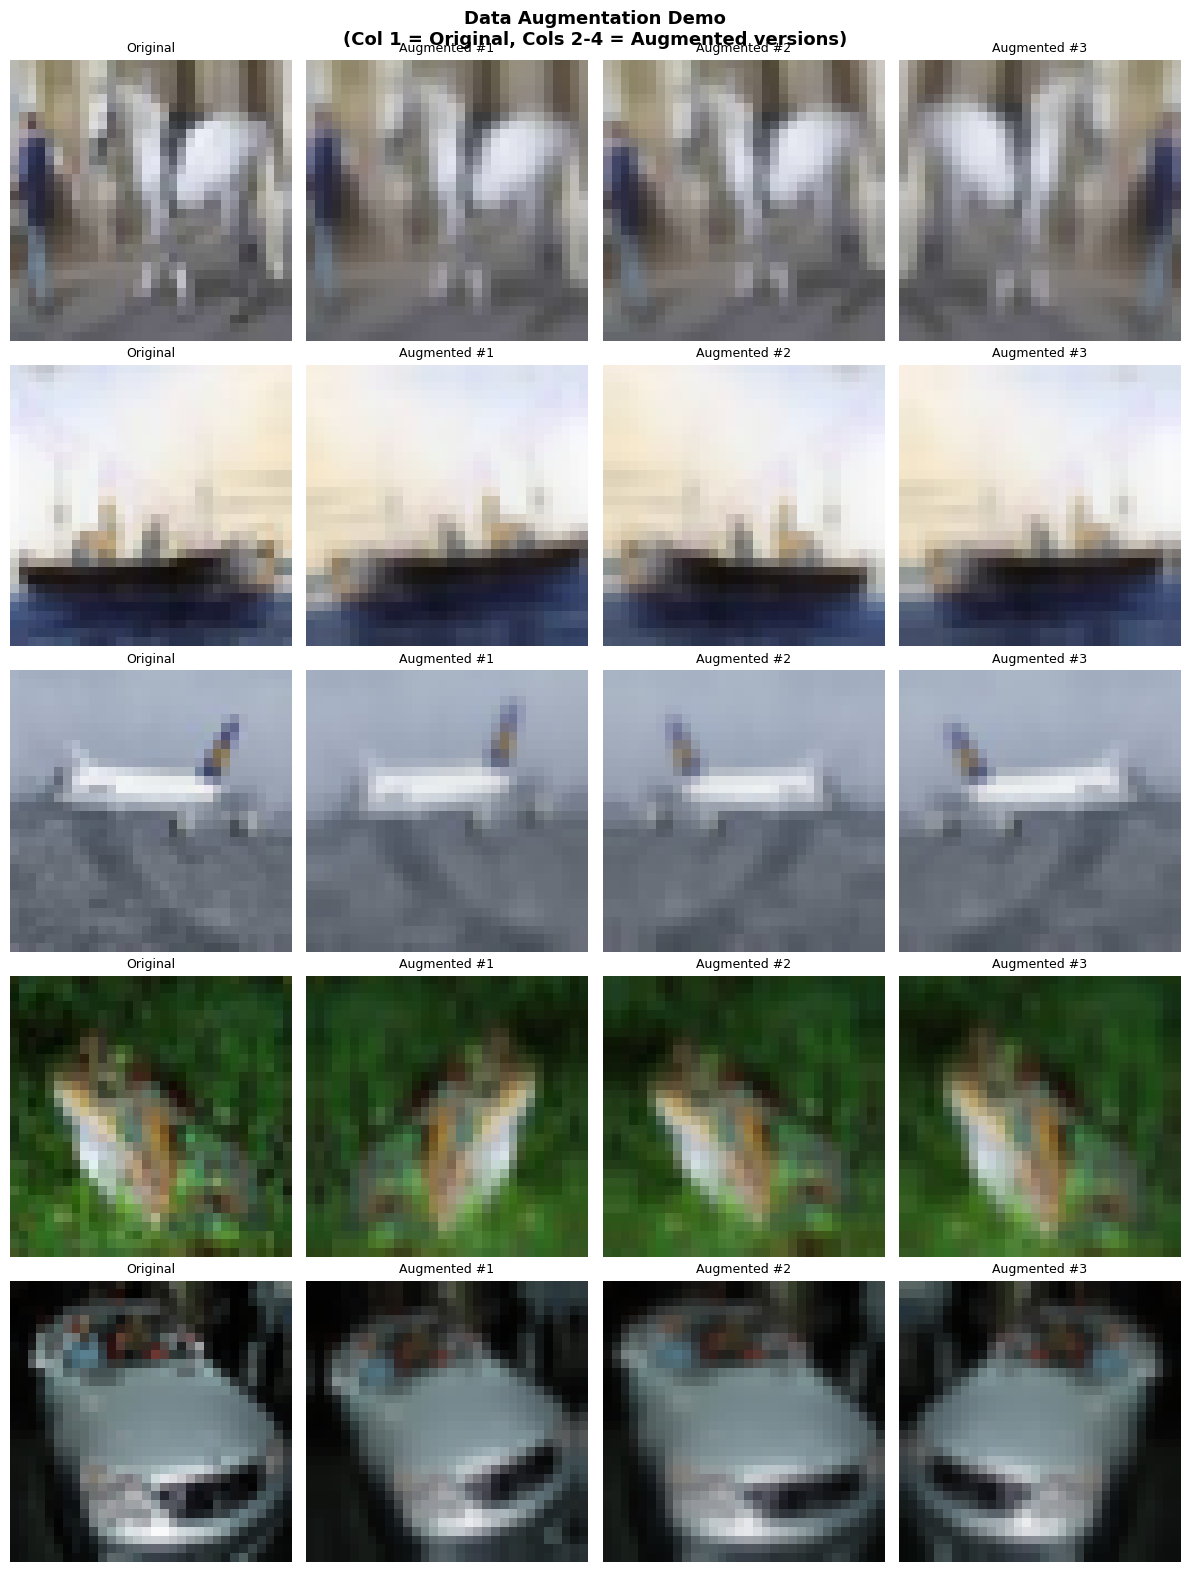

Saved: augmentation_demo.png


In [34]:
import tensorflow as tf

# Build augmentation pipeline using Keras Sequential layers
# Applied ONLY during training — never on validation or test sets.
cifar_augmenter = tf.keras.Sequential([
    # (a) Horizontal flip with probability 0.5
    tf.keras.layers.RandomFlip('horizontal'),
    # (b) Random rotation ±10 degrees  (factor = degrees/360)
    tf.keras.layers.RandomRotation(factor=10/360),
    # (c) Random zoom up to 10%
    tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1),
], name='cifar_augmenter')

# ── Visualise augmentations on 5 CIFAR-10 images ──────────────────────────────
np.random.seed(42)
sample_indices = np.random.choice(len(cifar_x_train_p), 5, replace=False)
sample_images = cifar_x_train_p[sample_indices]   # shape (5, 32, 32, 3)

fig, axes = plt.subplots(5, 4, figsize=(12, 16))
fig.suptitle('Data Augmentation Demo\n(Col 1 = Original, Cols 2-4 = Augmented versions)',
             fontsize=13, fontweight='bold')

for row in range(5):
    # Column 0: original image
    axes[row, 0].imshow(sample_images[row])
    axes[row, 0].set_title('Original', fontsize=9)
    axes[row, 0].axis('off')

    # Columns 1-3: three different augmented versions
    for col in range(1, 4):
        aug_img = cifar_augmenter(
            sample_images[row:row+1], training=True   # training=True activates augmentation
        )[0].numpy()
        aug_img = np.clip(aug_img, 0.0, 1.0)          # clip after zoom to keep valid range
        axes[row, col].imshow(aug_img)
        axes[row, col].set_title(f'Augmented #{col}', fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: augmentation_demo.png")

**Written Justification — Why augmentation must ONLY be applied to the training set:**

Data augmentation randomly transforms images (flips, rotations, zooms) to artificially increase the size and diversity of the training set, helping the model generalise and not overfit specific pixel patterns. If augmentation were applied to the **validation set**, the model would be evaluated on modified images that do not reflect the true data distribution, making validation accuracy an unreliable estimate of real-world performance. Applying it to the **test set** would be even worse — the final reported accuracy would no longer represent how the model performs on real, unaltered images, invalidating the entire evaluation. The test set must remain untouched to serve as an unbiased proxy for the real world.

**Note for MNIST:** Horizontal flips are label-destroying for MNIST (a flipped '6' looks like a '9', flipped '2' is ambiguous), so horizontal flips should be **disabled** for MNIST. Only label-preserving augmentations (small rotations, slight zoom) should be used on MNIST.

## Task 1 — Analysis & Reflection Questions

**Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)?**

The tensor `(N, H, W, C)` represents a batch of N images, each of height H and width W, with C channels. The **channel dimension C** encodes different types of information at every spatial location. For a **greyscale image**, C=1 because there is only a single intensity value per pixel (how bright that pixel is). For an **RGB image**, C=3 because each pixel has three values — one for Red intensity, one for Green, and one for Blue — and their combination produces colour. In a CNN, deeper convolutional layers produce feature maps where C can be 32, 64, or more — each channel then represents a different learned feature (e.g., one channel might activate on horizontal edges, another on colour blobs).

---

**Q2. If training on 1024×1024 satellite images, what strategies would avoid running out of memory?**

1. **Patch-based loading / tiling:** Instead of loading the full 1024×1024 image at once, cut each image into smaller non-overlapping patches (e.g., 128×128) and feed patches as individual samples. This dramatically reduces the memory required per batch while still allowing the model to learn local spatial features.

2. **`tf.data.Dataset` with lazy loading + prefetch:** Rather than loading all images into RAM at once (as `numpy` arrays), use `tf.data.Dataset.from_generator()` or `map()` with `prefetch(AUTOTUNE)`. This loads each batch from disk on-demand in a background thread while the GPU trains on the previous batch, keeping memory usage proportional to batch size rather than dataset size.

---

**Q3. What is wrong with normalising the test set using the test set's own mean and standard deviation?**

This is a form of **data leakage**. The mean and standard deviation computed from the test set encode statistical information about the test examples themselves. When these are used for normalisation, the model effectively receives hidden information about the test distribution during evaluation, making the test set no longer a clean, independent proxy for the real world. The correct approach is to compute mean and standard deviation **only from the training set** and apply those same values to both the validation and test sets. This mirrors the real deployment scenario where you cannot know the statistics of future, unseen data in advance.